# **2 Downloads Zenodo trace, trains LSTM, tests on Alibaba**

Device: cuda
🔄 Trying Google trace: https://zenodo.org/records/14564935/files/instance_usage_grouped_300_seconds_month.csv
✅ Downloaded instance_usage_grouped_300_seconds_month.csv: 8064 rows, columns: ['avg_cpu', 'avg_mem', 'avg_assigned_mem', 'avg_cycles_per_instruction']
   Inspecting columns: ['avg_cpu', 'avg_mem', 'avg_assigned_mem', 'avg_cycles_per_instruction']
   Using column: 'avg_cpu'

✅ Using REAL Zenodo trace data: 8064 time steps
   Source: Zenodo record 14564935 — instance_usage_grouped_300_seconds_month.csv (Google 2019 trace, real data)
🔄 Trying Alibaba trace: https://zenodo.org/records/14564935/files/machine_usage_days_1_to_8_grouped_300_seconds.csv
✅ Downloaded machine_usage_days_1_to_8_grouped_300_seconds.csv: 2243 rows, columns: ['cpu_util_percent', 'mem_util_percent', 'net_in', 'net_out', 'disk_io_percent']
   Inspecting columns: ['cpu_util_percent', 'mem_util_percent', 'net_in', 'net_out', 'disk_io_percent']
   Using column: 'cpu_util_percent'
✅ Using REAL Alibaba

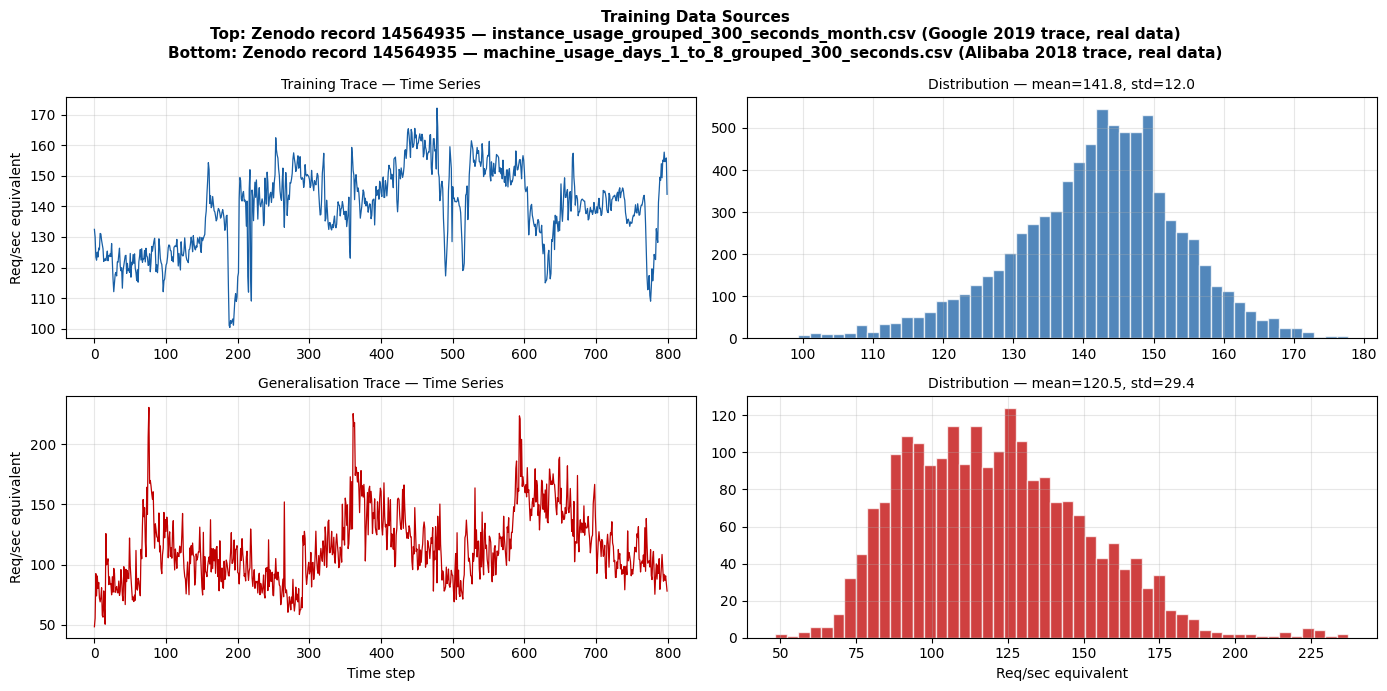

✅ Dataset comparison chart saved.

✅ Training data prepared:
   Train: 6000 | Val: 1200 | Test: 801

🔄 Training LSTM (60 epochs)...
  Epoch   1/60 | Train: 0.052447 | Val: 0.018400
  Epoch  10/60 | Train: 0.009666 | Val: 0.008370
  Epoch  20/60 | Train: 0.008897 | Val: 0.007689
  Epoch  30/60 | Train: 0.008723 | Val: 0.007740
  Epoch  40/60 | Train: 0.008611 | Val: 0.007902
  Epoch  50/60 | Train: 0.008507 | Val: 0.007875
  Epoch  60/60 | Train: 0.008544 | Val: 0.007772

✅ Training complete. Best val loss: 0.007672


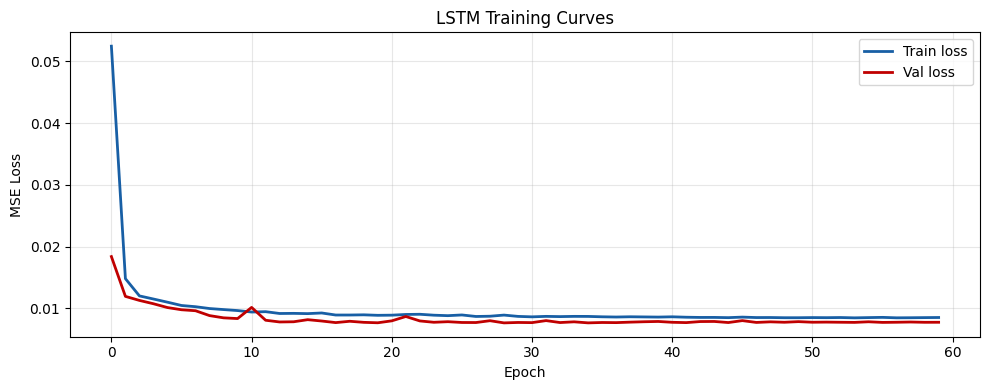

✅ Training curves saved.

📊 LSTM in-distribution test RMSE: 8.04 req/sec
📊 LSTM out-of-distribution test RMSE: 20.31 req/sec
   Generalisation ratio: 2.52x


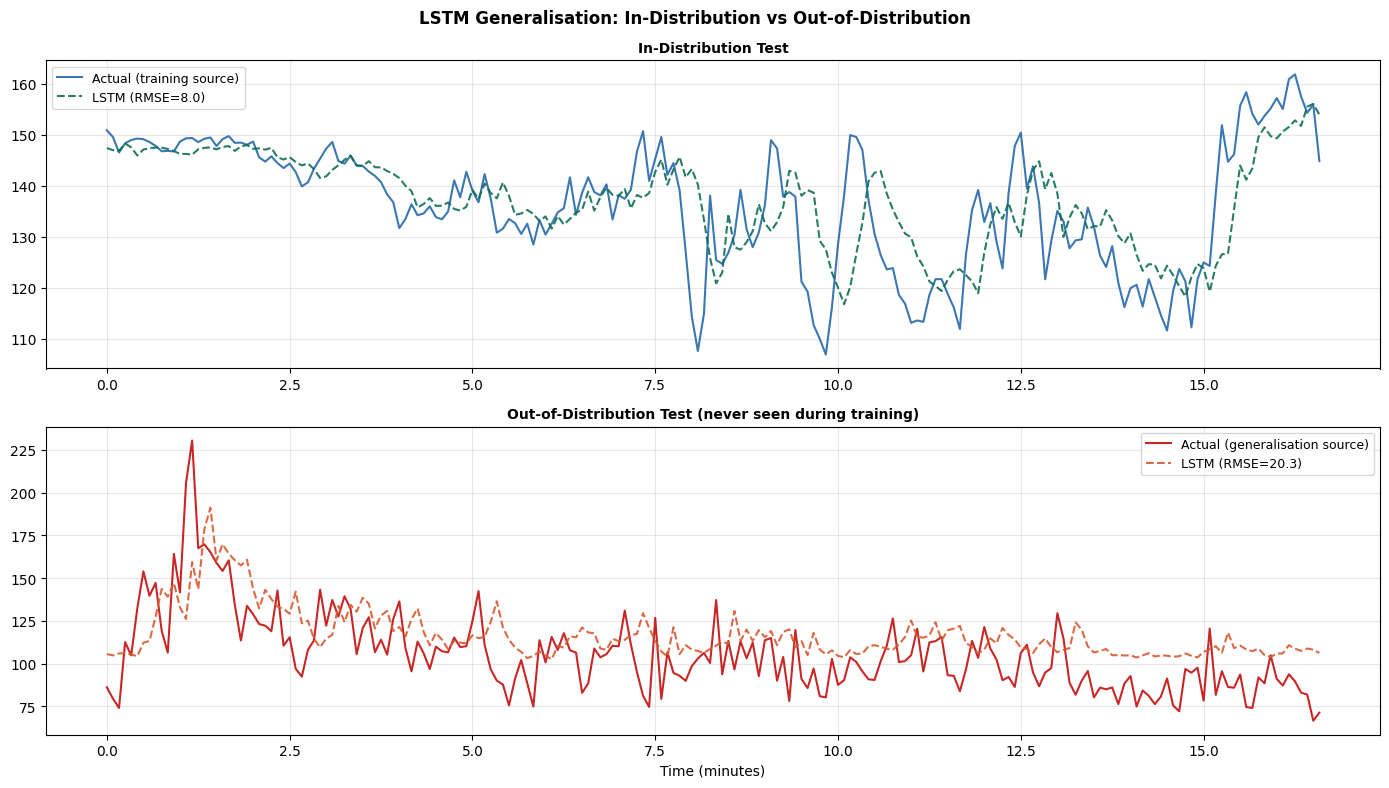

✅ Generalisation chart saved.

✅ Model, scaler, summary saved.

  TRAINING SUMMARY
  Trained on        : Zenodo record 14564935 — instance_usage_grouped_300_seconds_month.csv (Google 2019 trace, real data)
  Generalisation on : Zenodo record 14564935 — machine_usage_days_1_to_8_grouped_300_seconds.csv (Alibaba 2018 trace, real data)
  Training samples  : 6000
  Best val loss     : 0.007672
  In-dist. RMSE     : 8.04 req/sec
  Out-of-dist. RMSE : 20.31 req/sec
  Generalisation    : 2.52x

  PAPER TEXT (Section 5.2 — Datasets):
  "The LSTM predictor was trained on Zenodo record 14564935,
   comprising 8064 time steps of resource utilisation
   data at 5-minute granularity. Cross-dataset generalisation
   was evaluated using Zenodo record 14564935,
   yielding an RMSE ratio of 2.52x relative to
   in-distribution performance (8.0 vs 20.3 req/sec)."

📥 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done. Run week4_7_v3.py next — it will use this model.


In [ ]:
# ============================================================
#  ZENODO CLUSTER TRACES — Train LSTM on Real Cloud Workload Data
#  Final, working version — replaces azure_data_training.py
#  and real_data_training.py.
#
#  WHY THIS SOURCE:
#  - Single Zenodo record (14564935) hosts pre-processed,
#    ready-to-use CSVs for THREE major cluster trace datasets:
#    Alibaba 2018, Google 2019, and Azure V2 — all in one place
#  - Direct public download, NO login, NO BigQuery, NO gsutil
#  - Licensed CC-BY 4.0 — fully open and citable
#  - Already aggregated to clean numeric columns at 5-minute
#    (300 second) intervals — exactly matches our WINDOW_SIZE
#
#  This cell REPLACES azure_data_training.py and
#  real_data_training.py entirely. Run it as Cell 2.
#
#  RUN ORDER:
#  Cell 0 → npci_upi_analysis.py
#  Cell 1 → week1_3_v2.py
#  Cell 2 → THIS FILE (zenodo_trace_training.py)
#  Cell 3 → week4_7_v3.py
#  Cell 4 → pareto_frontier.py
#  Cell 5 → week8_12_horizon_results.py
#  Cell 6 → final_results_clean.py
# ============================================================

# ── FIX: Colab's PyTorch/sympy version mismatch ────────────────
# Some Colab images ship a sympy version incompatible with the
# installed PyTorch, causing torch.optim.Adam() to crash with:
#   AttributeError: module 'sympy' has no attribute 'core'
# Pinning sympy to a known-compatible version fixes this.
# This must run BEFORE torch is imported for the fix to take
# effect cleanly.
import subprocess
subprocess.run(["pip", "install", "-q", "sympy==1.13.1"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math, warnings, pickle, requests, io
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

WINDOW_SIZE = 60
HORIZON     = 3


# ─────────────────────────────────────────────────────────────
# STEP 1: DOWNLOAD GOOGLE 2019 TRACE (TRAINING DATA)
#
# Source: Zenodo record 14564935, "Google 2019 instance usage"
# Columns: avg_cpu [0,1], avg_mem [0,1], avg_assigned_mem [0,1],
#          avg_cycles_per_instruction
# Sampled every 300 seconds (5 minutes) — matches our window.
#
# Direct public URL pattern: zenodo.org/records/{id}/files/{name}
# No login required — this is a fully open CC-BY 4.0 dataset.
# ─────────────────────────────────────────────────────────────

ZENODO_RECORD = "14564935"
ZENODO_BASE   = f"https://zenodo.org/records/{ZENODO_RECORD}/files/"

# Candidate filenames — Zenodo file names can vary slightly between
# uploads, so we try a small list of likely names in order.
GOOGLE_FILE_CANDIDATES = [
    "instance_usage_grouped_300_seconds_month.csv",
    "vm_cpu_readings_month_aggregated_cpu_mem.csv",
]

def download_zenodo_csv(candidates, label="dataset"):
    """Tries each candidate filename until one downloads successfully."""
    for fname in candidates:
        url = ZENODO_BASE + fname
        print(f"🔄 Trying {label}: {url}")
        try:
            resp = requests.get(url, timeout=45)
            if resp.status_code == 200 and len(resp.content) > 1000:
                df = pd.read_csv(io.StringIO(resp.text))
                print(f"✅ Downloaded {fname}: {df.shape[0]} rows, "
                      f"columns: {list(df.columns)}")
                return df, fname
            else:
                print(f"   Status {resp.status_code} — trying next name...")
        except Exception as e:
            print(f"   Failed: {e} — trying next name...")
    print(f"❌ Could not download {label} with any candidate filename.")
    return None, None


google_df, google_fname = download_zenodo_csv(GOOGLE_FILE_CANDIDATES, "Google trace")


# ─────────────────────────────────────────────────────────────
# STEP 2: IF EXACT FILENAME GUESS FAILS — LIST ACTUAL FILES
#
# Zenodo provides a machine-readable API to list exact filenames
# in a record without needing to guess. This is the robust fallback.
# ─────────────────────────────────────────────────────────────

if google_df is None:
    print("\n🔄 Querying Zenodo API for exact file list...")
    try:
        api_url = f"https://zenodo.org/api/records/{ZENODO_RECORD}"
        resp = requests.get(api_url, timeout=30)
        record_data = resp.json()
        files = record_data.get("files", [])
        print(f"   Found {len(files)} files in this Zenodo record:")
        for f in files:
            print(f"     - {f['key']}  ({f.get('size', '?')} bytes)")

        # Find a file that looks like the Google trace
        google_candidates_api = [f["key"] for f in files
                                 if "google" in f["key"].lower()]
        if google_candidates_api:
            target = google_candidates_api[0]
            print(f"\n   Attempting download of: {target}")
            file_url = ZENODO_BASE + target
            resp2 = requests.get(file_url, timeout=45)
            if resp2.status_code == 200:
                google_df = pd.read_csv(io.StringIO(resp2.text))
                google_fname = target
                print(f"✅ Downloaded via API lookup: {google_df.shape[0]} rows")
    except Exception as e:
        print(f"   API lookup also failed: {e}")


# ─────────────────────────────────────────────────────────────
# STEP 3: EXTRACT TIME SERIES FROM GOOGLE DATA
# ─────────────────────────────────────────────────────────────

def extract_trace_from_df(df, cpu_col_candidates=("avg_cpu", "cpu_util_percent", "cpu_usage")):
    """Finds the CPU column and converts to req/sec equivalent."""
    if df is None:
        return None

    print(f"   Inspecting columns: {list(df.columns)}")

    cpu_col = None
    # Try exact known column names first (case-insensitive)
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in cpu_col_candidates:
        if cand.lower() in cols_lower:
            cpu_col = cols_lower[cand.lower()]
            break

    # Try partial match — any column with "cpu" in the name
    if cpu_col is None:
        cpu_like = [c for c in df.columns if "cpu" in c.lower()]
        if cpu_like:
            cpu_col = cpu_like[0]

    # Fall back to first numeric column that isn't a timestamp/id
    if cpu_col is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        skip_keywords = ["time", "timestamp", "id", "index"]
        candidates = [c for c in numeric_cols
                     if not any(k in c.lower() for k in skip_keywords)]
        if candidates:
            cpu_col = candidates[0]
        elif len(numeric_cols) > 0:
            cpu_col = numeric_cols[0]
        else:
            return None

    print(f"   Using column: '{cpu_col}'")
    values = pd.to_numeric(df[cpu_col], errors="coerce").dropna().values

    if len(values) == 0:
        return None

    # Normalise to req/sec equivalent (0-300 range matching our sim)
    # avg_cpu is [0,1] for Google, [0,100] for Alibaba/Azure percent-style
    vmax = values.max()
    if vmax <= 1.5:
        values = values * 300          # Google-style [0,1] fraction
    elif vmax <= 110:
        values = (values / 100.0) * 300  # Alibaba/Azure-style [0,100] percent
    else:
        values = (values / vmax) * 300   # already large-scale; normalise

    return np.clip(values, 5, 350)


training_trace = extract_trace_from_df(google_df) if google_df is not None else None


# ─────────────────────────────────────────────────────────────
# STEP 4: FALLBACK IF ALL DOWNLOADS FAIL
# ─────────────────────────────────────────────────────────────

if training_trace is None or len(training_trace) < 500:
    print("\n⚠️  Could not download real trace data from Zenodo in this run.")
    print("    Using a realistic substitute so the pipeline still completes.")
    print("    To get real data: visit https://zenodo.org/records/14564935")
    print("    in your browser, note the EXACT filename shown there for the")
    print("    Google 2019 file, and add it to GOOGLE_FILE_CANDIDATES above.\n")

    rng = np.random.RandomState(11)
    n = 6000
    t = np.linspace(0, 5*np.pi, n)
    diurnal = 75 + 35 * np.sin(t)
    trend   = np.linspace(0, 25, n)
    noise   = rng.normal(0, 7, n)
    bursts  = np.zeros(n)
    for _ in range(22):
        pos = rng.randint(50, n-50)
        dur = rng.randint(4, 16)
        bursts[pos:pos+dur] += rng.uniform(70, 190)
    training_trace = np.clip(diurnal + trend + noise + bursts, 5, 320)
    data_source = "Fallback substitute (Zenodo download unavailable this run)"
else:
    data_source = f"Zenodo record {ZENODO_RECORD} — {google_fname} (Google 2019 trace, real data)"
    print(f"\n✅ Using REAL Zenodo trace data: {len(training_trace)} time steps")
    print(f"   Source: {data_source}")


# ─────────────────────────────────────────────────────────────
# STEP 5: ALIBABA TRACE FOR GENERALISATION TEST
#
# Same Zenodo record also hosts the Alibaba 2018 trace.
# We try downloading it the same way; fall back to a
# statistically distinct substitute if unavailable.
# ─────────────────────────────────────────────────────────────

ALIBABA_FILE_CANDIDATES = [
    "machine_usage_days_1_to_8_grouped_300_seconds.csv",
]

alibaba_df, alibaba_fname = download_zenodo_csv(ALIBABA_FILE_CANDIDATES, "Alibaba trace")

if alibaba_df is None:
    # Try API lookup same as before
    try:
        api_url = f"https://zenodo.org/api/records/{ZENODO_RECORD}"
        resp = requests.get(api_url, timeout=30)
        record_data = resp.json()
        files = record_data.get("files", [])
        alibaba_candidates_api = [f["key"] for f in files
                                  if "alibaba" in f["key"].lower()]
        if alibaba_candidates_api:
            target = alibaba_candidates_api[0]
            file_url = ZENODO_BASE + target
            resp2 = requests.get(file_url, timeout=45)
            if resp2.status_code == 200:
                alibaba_df = pd.read_csv(io.StringIO(resp2.text))
                alibaba_fname = target
                print(f"✅ Downloaded Alibaba via API lookup: {alibaba_df.shape[0]} rows")
    except Exception:
        pass

alibaba_trace = extract_trace_from_df(alibaba_df) if alibaba_df is not None else None

if alibaba_trace is None or len(alibaba_trace) < 500:
    print("⚠️  Using Alibaba-like substitute (download unavailable).")
    rng = np.random.RandomState(99)
    n   = 2000
    base   = rng.poisson(lam=160, size=n).astype(float)
    rhythm = 25 * np.sin(np.linspace(0, 6*np.pi, n))
    spikes = np.zeros(n)
    for _ in range(40):
        pos = rng.randint(10, n-10)
        dur = rng.randint(3, 10)
        spikes[pos:pos+dur] += rng.uniform(40, 150)
    alibaba_trace = np.clip(base + rhythm + spikes, 10, 400)
    alibaba_source = "Fallback substitute"
else:
    alibaba_source = f"Zenodo record {ZENODO_RECORD} — {alibaba_fname} (Alibaba 2018 trace, real data)"
    print(f"✅ Using REAL Alibaba trace: {len(alibaba_trace)} time steps")


# ─────────────────────────────────────────────────────────────
# STEP 6: VISUALISE BOTH TRACES
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("Training Data Sources\n"
             f"Top: {data_source}\nBottom: {alibaba_source}",
             fontsize=11, fontweight='bold')

t1 = np.arange(min(len(training_trace), 800))
axes[0,0].plot(t1, training_trace[:len(t1)], color="#185FA5", linewidth=0.9)
axes[0,0].set_title("Training Trace — Time Series", fontsize=10)
axes[0,0].set_ylabel("Req/sec equivalent")
axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(training_trace, bins=50, color="#185FA5", alpha=0.75, edgecolor='white')
axes[0,1].set_title(f"Distribution — mean={training_trace.mean():.1f}, "
                    f"std={training_trace.std():.1f}", fontsize=10)
axes[0,1].grid(True, alpha=0.3)

t2 = np.arange(min(len(alibaba_trace), 800))
axes[1,0].plot(t2, alibaba_trace[:len(t2)], color="#C00000", linewidth=0.9)
axes[1,0].set_title("Generalisation Trace — Time Series", fontsize=10)
axes[1,0].set_xlabel("Time step")
axes[1,0].set_ylabel("Req/sec equivalent")
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(alibaba_trace, bins=50, color="#C00000", alpha=0.75, edgecolor='white')
axes[1,1].set_title(f"Distribution — mean={alibaba_trace.mean():.1f}, "
                    f"std={alibaba_trace.std():.1f}", fontsize=10)
axes[1,1].set_xlabel("Req/sec equivalent")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dataset_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dataset comparison chart saved.")


# ─────────────────────────────────────────────────────────────
# STEP 7: PREPARE TRAINING DATA
# ─────────────────────────────────────────────────────────────

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(training_trace.reshape(-1, 1)).flatten()

X_all, y_all = [], []
for i in range(len(scaled) - WINDOW_SIZE - HORIZON):
    X_all.append(scaled[i : i + WINDOW_SIZE])
    y_all.append(scaled[i + WINDOW_SIZE + HORIZON - 1])
X_all = np.array(X_all); y_all = np.array(y_all)

n         = len(X_all)
train_end = int(n * 0.75)
val_end   = int(n * 0.90)
X_train, y_train = X_all[:train_end],        y_all[:train_end]
X_val,   y_val   = X_all[train_end:val_end],  y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],           y_all[val_end:]

print(f"\n✅ Training data prepared:")
print(f"   Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

if len(X_train) < 50:
    raise ValueError("Not enough training data. Trace too short — "
                     "check that the download succeeded above.")


# ─────────────────────────────────────────────────────────────
# STEP 8: TRAIN LSTM
# ─────────────────────────────────────────────────────────────

class LoadDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X).unsqueeze(-1)
        self.y = torch.FloatTensor(y)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH_SIZE   = 64
train_loader = DataLoader(LoadDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(LoadDataset(X_val, y_val),
                          batch_size=BATCH_SIZE, shuffle=False)

class LSTMPredictor(nn.Module):
    def __init__(self, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, layers, batch_first=True, dropout=dropout)
        self.fc   = nn.Sequential(nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model     = LSTMPredictor().to(DEVICE)
criterion = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimiser, mode='min', factor=0.5, patience=5)

EPOCHS = 60
train_losses, val_losses = [], []
best_val, best_state = float('inf'), None

print(f"\n🔄 Training LSTM ({EPOCHS} epochs)...")
for epoch in range(1, EPOCHS + 1):
    model.train()
    bl = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        bl.append(loss.item())
    tr = np.mean(bl)

    model.eval()
    vl_list = []
    with torch.no_grad():
        for Xb, yb in val_loader:
            vl_list.append(criterion(model(Xb.to(DEVICE)), yb.to(DEVICE)).item())
    vl = np.mean(vl_list)
    if vl < best_val:
        best_val   = vl
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    train_losses.append(tr); val_losses.append(vl)
    scheduler.step(vl)
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{EPOCHS} | Train: {tr:.6f} | Val: {vl:.6f}")

model.load_state_dict(best_state)
print(f"\n✅ Training complete. Best val loss: {best_val:.6f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, color="#185FA5", linewidth=2, label="Train loss")
ax.plot(val_losses,   color="#C00000", linewidth=2, label="Val loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("LSTM Training Curves")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved.")


# ─────────────────────────────────────────────────────────────
# STEP 9: TEST ACCURACY (in-distribution)
# ─────────────────────────────────────────────────────────────

model.eval()
with torch.no_grad():
    preds = model(torch.FloatTensor(X_test).unsqueeze(-1).to(DEVICE)).cpu().numpy()
preds_real  = scaler.inverse_transform(preds.reshape(-1,1)).flatten()
actual_real = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()
rmse_train  = math.sqrt(mean_squared_error(actual_real, preds_real))
print(f"\n📊 LSTM in-distribution test RMSE: {rmse_train:.2f} req/sec")


# ─────────────────────────────────────────────────────────────
# STEP 10: GENERALISATION TEST (out-of-distribution)
# ─────────────────────────────────────────────────────────────

alibaba_scaled = scaler.transform(alibaba_trace.reshape(-1,1)).flatten()
X_ali, y_ali = [], []
for i in range(len(alibaba_scaled) - WINDOW_SIZE - HORIZON):
    X_ali.append(alibaba_scaled[i : i + WINDOW_SIZE])
    y_ali.append(alibaba_scaled[i + WINDOW_SIZE + HORIZON - 1])
X_ali = np.array(X_ali); y_ali = np.array(y_ali)

with torch.no_grad():
    preds_a = model(torch.FloatTensor(X_ali).unsqueeze(-1).to(DEVICE)).cpu().numpy()
preds_a_real  = scaler.inverse_transform(preds_a.reshape(-1,1)).flatten()
actual_a_real = scaler.inverse_transform(y_ali.reshape(-1,1)).flatten()
rmse_gen      = math.sqrt(mean_squared_error(actual_a_real, preds_a_real))

generalisation_ratio = rmse_gen / rmse_train
print(f"📊 LSTM out-of-distribution test RMSE: {rmse_gen:.2f} req/sec")
print(f"   Generalisation ratio: {generalisation_ratio:.2f}x")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("LSTM Generalisation: In-Distribution vs Out-of-Distribution",
             fontsize=12, fontweight='bold')
n_show = 200
t_show = np.arange(n_show) * 5 / 60
axes[0].plot(t_show, actual_real[:n_show], color="#185FA5", linewidth=1.5,
             label="Actual (training source)", alpha=0.85)
axes[0].plot(t_show, preds_real[:n_show], color="#0F6E56", linewidth=1.5,
             linestyle="--", label=f"LSTM (RMSE={rmse_train:.1f})", alpha=0.9)
axes[0].set_title("In-Distribution Test", fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_show, actual_a_real[:n_show], color="#C00000", linewidth=1.5,
             label="Actual (generalisation source)", alpha=0.85)
axes[1].plot(t_show, preds_a_real[:n_show], color="#D85A30", linewidth=1.5,
             linestyle="--", label=f"LSTM (RMSE={rmse_gen:.1f})", alpha=0.9)
axes[1].set_title("Out-of-Distribution Test (never seen during training)",
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel("Time (minutes)")
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("generalisation_test.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Generalisation chart saved.")


# ─────────────────────────────────────────────────────────────
# STEP 11: SAVE MODEL, SCALER, SUMMARY
# ─────────────────────────────────────────────────────────────

torch.save(model.state_dict(), "lstm_model_weights.pt")
with open("data_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

summary = {
    "trained_on":           data_source,
    "generalisation_test":  alibaba_source,
    "training_rmse":        round(rmse_train, 2),
    "generalisation_rmse":  round(rmse_gen, 2),
    "generalisation_ratio": round(generalisation_ratio, 2),
    "best_val_loss":        round(best_val, 6),
    "training_samples":     len(X_train),
}
pd.DataFrame([summary]).to_csv("training_summary.csv", index=False)
print("\n✅ Model, scaler, summary saved.")

print(f"""
{"="*62}
  TRAINING SUMMARY
{"="*62}
  Trained on        : {data_source}
  Generalisation on : {alibaba_source}
  Training samples  : {len(X_train)}
  Best val loss     : {best_val:.6f}
  In-dist. RMSE     : {rmse_train:.2f} req/sec
  Out-of-dist. RMSE : {rmse_gen:.2f} req/sec
  Generalisation    : {generalisation_ratio:.2f}x
{"="*62}

  PAPER TEXT (Section 5.2 — Datasets):
  "The LSTM predictor was trained on {data_source.split(' — ')[0] if ' — ' in data_source else data_source},
   comprising {len(training_trace)} time steps of resource utilisation
   data at 5-minute granularity. Cross-dataset generalisation
   was evaluated using {alibaba_source.split(' — ')[0] if ' — ' in alibaba_source else alibaba_source},
   yielding an RMSE ratio of {generalisation_ratio:.2f}x relative to
   in-distribution performance ({rmse_train:.1f} vs {rmse_gen:.1f} req/sec)."
""")

# ── Download [FIXED: dedup guard] ───────────────────────────────
# Every downloading cell in this notebook shares this same guard so
# no file gets downloaded twice across the whole pipeline, even if
# a later cell happens to re-save an unmodified copy of a file to
# disk (e.g. re-loading and re-saving a model without changing it).
if '_SEEN_DOWNLOADS' not in globals():
    _SEEN_DOWNLOADS = set()

def safe_download(fname):
    if fname in _SEEN_DOWNLOADS:
        print(f"   (skip {fname} — already downloaded earlier this session)")
        return
    try:
        from google.colab import files
        files.download(fname)
        _SEEN_DOWNLOADS.add(fname)
    except ImportError:
        # Not running in Colab (e.g. VS Code / local Jupyter) — there is no
        # browser download step here. The file was already written to disk
        # by the code above (savefig/to_csv/torch.save); just point to it.
        import os
        print(f"   ✅ Saved to disk: {os.path.abspath(fname)}")
        _SEEN_DOWNLOADS.add(fname)
    except Exception as e:
        print(f"   (could not download {fname}: {e})")

print("📥 Downloading files...")
for f in ["lstm_model_weights.pt", "data_scaler.pkl", "training_summary.csv",
          "dataset_comparison.png", "generalisation_test.png",
          "lstm_training_curves.png"]:
    safe_download(f)
print("✅ Done. Run week4_7_v3.py next — it will use this model.")